# Challenge Telecom X:
### Análisis de evasión de clientes - Parte 2

In [33]:
import pandas as pd

df = pd.read_csv('/content/datos_tratados.csv')

df.head()

,customerID,Churn,gender,senior_citizen,partner,dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,contract,paperlessBilling,payment_method,monthly_charges,total_charges,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0.0,DSL,...,0.0,1.0,1.0,0.0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1.0,DSL,...,0.0,0.0,0.0,1.0,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0.0,Fiber optic,...,1.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0.0,Fiber optic,...,1.0,0.0,1.0,1.0,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0.0,Fiber optic,...,0.0,1.0,1.0,0.0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   int64  
 2   gender                     7267 non-null   object 
 3   senior_citizen             7267 non-null   int64  
 4   partner                    7267 non-null   int64  
 5   dependents                 7267 non-null   int64  
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   int64  
 8   phone.MultipleLines        6560 non-null   float64
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    5686 non-null   float64
 11  internet.OnlineBackup      5686 non-null   float64
 12  internet.DeviceProtection  5686 non-null   float64
 13  internet.TechSupport       5686 non-null   float

In [35]:
df = df.drop(columns = ['customerID'])

In [36]:
print(df["phone.MultipleLines"].unique())

[ 0.  1. nan]


In [37]:
df["phone.MultipleLines"] = df["phone.MultipleLines"].fillna(0)
df["internet.OnlineSecurity"] = df["internet.OnlineSecurity"].fillna(0)
df["internet.OnlineBackup"] = df["internet.OnlineBackup"].fillna(0)
df["internet.DeviceProtection"] = df["internet.DeviceProtection"].fillna(0)
df["internet.TechSupport"] = df["internet.TechSupport"].fillna(0)
df["internet.StreamingTV"] = df["internet.StreamingTV"].fillna(0)
df["internet.StreamingMovies"] = df["internet.StreamingMovies"].fillna(0)

In [38]:
df['phone.MultipleLines'].isna().sum()

np.int64(0)

In [39]:
df["phone.MultipleLines"] = df["phone.MultipleLines"].astype(int)
df["internet.OnlineSecurity"] = df["internet.OnlineSecurity"].astype(int)
df["internet.OnlineBackup"] = df["internet.OnlineBackup"].astype(int)
df["internet.DeviceProtection"] = df["internet.DeviceProtection"].astype(int)
df["internet.TechSupport"] = df["internet.TechSupport"].astype(int)
df["internet.StreamingTV"] = df["internet.StreamingTV"].astype(int)
df["internet.StreamingMovies"] = df["internet.StreamingMovies"].astype(int)

In [40]:
cat_cols = df.select_dtypes(include=["object"]).columns
print(cat_cols)

Index(['gender', 'internet.InternetService', 'contract', 'payment_method'], dtype='object')


In [41]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [42]:
print(df_encoded.shape)
print(df_encoded.head())

(7267, 25)
   Churn  senior_citizen  partner  dependents  customer.tenure  \
0      0               0        1           1                9   
1      0               0        0           0                9   
2      1               0        0           0                4   
3      1               1        1           0               13   
4      1               1        1           0                3   

   phone.PhoneService  phone.MultipleLines  internet.OnlineSecurity  \
0                   1                    0                        0   
1                   1                    1                        0   
2                   1                    0                        0   
3                   1                    0                        0   
4                   1                    0                        0   

   internet.OnlineBackup  internet.DeviceProtection  ...  total_charges  \
0                      1                          0  ...         593.30   
1              

In [43]:
df_encoded.dtypes.value_counts()

,count
int64,14
bool,8
float64,3


In [44]:
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [45]:
df_encoded

,Churn,senior_citizen,partner,dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,...,total_charges,Cuentas_Diarias,gender_Male,internet.InternetService_Fiber optic,internet.InternetService_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,593.30,2.19,0,0,0,1,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,...,542.40,2.00,1,0,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,...,280.85,2.46,1,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,...,1237.85,3.27,1,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,...,267.40,2.80,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,0,0,0,13,1,0,1,0,0,...,742.90,1.84,0,0,0,1,0,0,0,1
7263,1,0,1,0,22,1,1,0,0,0,...,1873.70,2.84,1,1,0,0,0,0,1,0
7264,0,0,0,0,2,1,0,0,1,0,...,92.75,1.68,1,0,0,0,0,0,0,1
7265,0,0,1,1,67,1,0,1,0,1,...,4627.65,2.26,1,0,0,0,1,0,0,1


In [46]:
df_encoded["Churn"].value_counts()

,count
Churn,
0,5398
1,1869


In [49]:
round(df_encoded["Churn"].value_counts(normalize=True)*100, 2)

,proportion
Churn,
0,74.28
1,25.72


La proporción de clientes que permanecen activos es mayor que la de clientes que cancelaron el servicio.
Aproximadamente el 75% de los clientes no cancelaron, mientras que el 25% sí lo hicieron.
Esto indica que existe un desbalance moderado entre las clases, lo cual puede afectar el desempeño de los modelos predictivos, ya que los algoritmos podrían sesgarse hacia la clase mayoritaria.

In [50]:
num_cols = df_encoded.select_dtypes(include=["int64", "float64"]).columns
print(num_cols)

Index(['Churn', 'senior_citizen', 'partner', 'dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.OnlineSecurity',
       'internet.OnlineBackup', 'internet.DeviceProtection',
       'internet.TechSupport', 'internet.StreamingTV',
       'internet.StreamingMovies', 'paperlessBilling', 'monthly_charges',
       'total_charges', 'Cuentas_Diarias', 'gender_Male',
       'internet.InternetService_Fiber optic', 'internet.InternetService_No',
       'contract_One year', 'contract_Two year',
       'payment_method_Credit card (automatic)',
       'payment_method_Electronic check', 'payment_method_Mailed check'],
      dtype='object')


In [51]:
num_cols = num_cols.drop("Churn")

In [52]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

In [54]:
X_scaled.head()

,senior_citizen,partner,dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,...,total_charges,Cuentas_Diarias,gender_Male,internet.InternetService_Fiber optic,internet.InternetService_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,-0.440736,1.032309,1.527075,-0.950200,0.32829,-0.854058,-0.632821,1.379187,-0.722195,1.566492,...,-0.742291,0.032567,-1.011487,-0.886534,-0.527306,1.945268,-0.561723,-0.524534,-0.712075,1.834275
1,-0.440736,-0.968702,-0.654847,-0.950200,0.32829,1.170881,-0.632821,-0.725065,-0.722195,-0.638369,...,-0.764729,-0.156613,0.988643,-0.886534,-0.527306,-0.514068,-0.561723,-0.524534,-0.712075,1.834275
2,-0.440736,-0.968702,-0.654847,-1.153700,0.32829,-0.854058,-0.632821,-0.725065,1.384667,-0.638369,...,-0.880026,0.301401,0.988643,1.127988,-0.527306,-0.514068,-0.561723,-0.524534,1.404346,-0.545175
3,2.268932,1.032309,-0.654847,-0.787401,0.32829,-0.854058,-0.632821,1.379187,1.384667,-0.638369,...,-0.458160,1.107902,0.988643,1.127988,-0.527306,-0.514068,-0.561723,-0.524534,1.404346,-0.545175
4,2.268932,1.032309,-0.654847,-1.194400,0.32829,-0.854058,-0.632821,-0.725065,-0.722195,1.566492,...,-0.885955,0.639932,-1.011487,1.127988,-0.527306,-0.514068,-0.561723,-0.524534,-0.712075,1.834275


Se evaluó la necesidad de normalizar o estandarizar los datos antes de entrenar los modelos.
Los modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, son sensibles a la escala de los datos, por lo que se aplicó estandarización utilizando StandardScaler.

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
corr_matrix = df_encoded.corr()
# plt.figure(figsize=(12,8))
# sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
# plt.title("Matriz de correlación")
# plt.show()

In [67]:
corr_churn = corr_matrix["Churn"].sort_values(ascending=False)
print(corr_churn)

Churn                                     1.000000
internet.InternetService_Fiber optic      0.300949
payment_method_Electronic check           0.294626
Cuentas_Diarias                           0.189918
monthly_charges                           0.189866
paperlessBilling                          0.186666
senior_citizen                            0.146733
internet.StreamingTV                      0.062430
internet.StreamingMovies                  0.060586
phone.MultipleLines                       0.039343
phone.PhoneService                        0.012571
gender_Male                              -0.009555
internet.DeviceProtection                -0.063452
internet.OnlineBackup                    -0.080163
payment_method_Mailed check              -0.090061
payment_method_Credit card (automatic)   -0.131085
partner                                  -0.148546
internet.TechSupport                     -0.160440
dependents                               -0.161384
internet.OnlineSecurity        

| Correlación | Significado             |
| ----------- | ----------------------- |
| cerca de 1  | muy relacionada         |
| cerca de -1 | relación inversa fuerte |
| cerca de 0  | poca relación           |


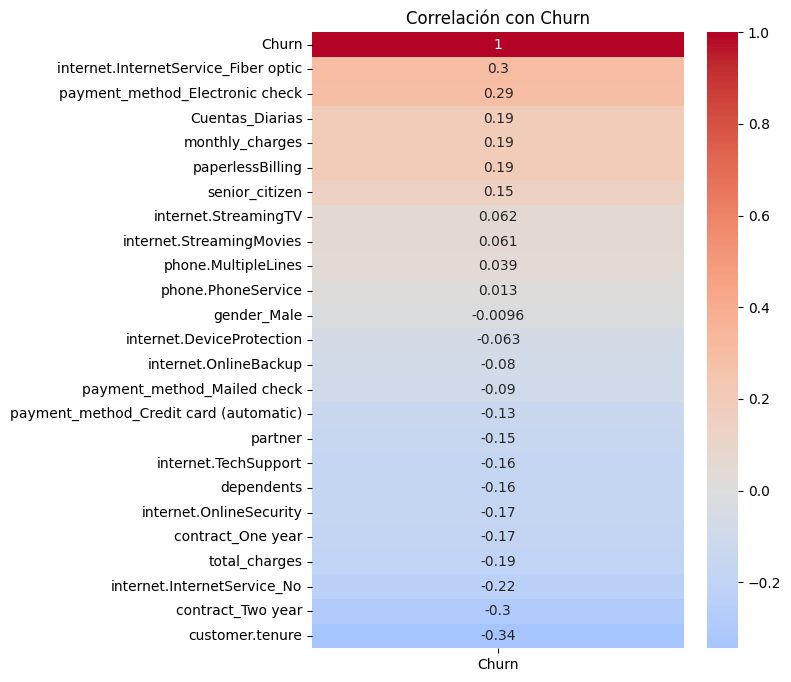

In [68]:
plt.figure(figsize=(6,8))
sns.heatmap(corr_matrix[["Churn"]].sort_values(by="Churn", ascending=False),
            annot=True,
            cmap="coolwarm",
            center=0)

plt.title("Correlación con Churn")
plt.show()

Se generó una matriz de correlación para analizar la relación entre las variables numéricas.
Se observó que algunas variables presentan mayor correlación con la variable objetivo Churn, lo que indica que pueden ser buenos predictores en los modelos de machine learning.

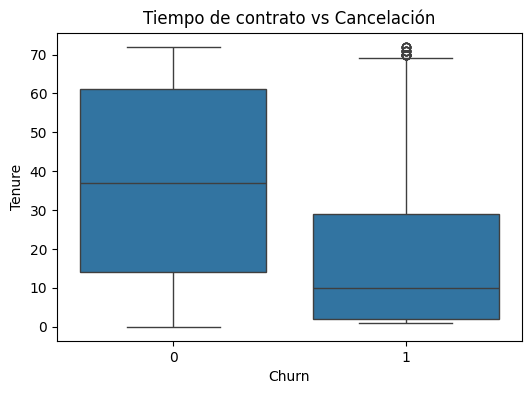

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x=df_encoded["Churn"], y=df_encoded["customer.tenure"])

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

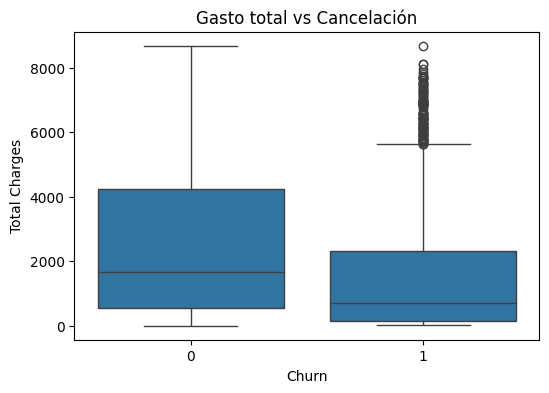

In [71]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_encoded["Churn"], y=df_encoded["total_charges"])

plt.title("Gasto total vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

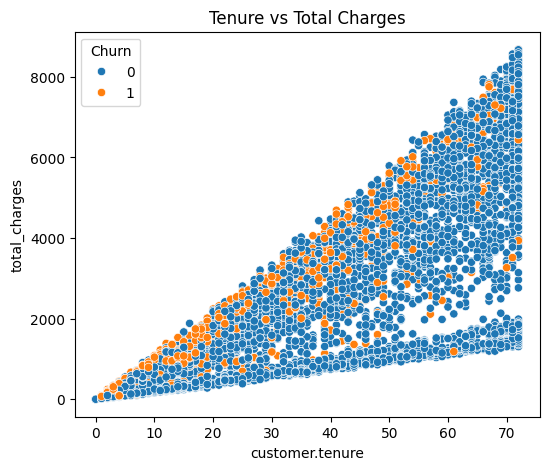

In [73]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x=df_encoded["customer.tenure"],
    y=df_encoded["total_charges"],
    hue=df_encoded["Churn"]
)

plt.title("Tenure vs Total Charges")
plt.show()

Se observó que los clientes que cancelan suelen tener menor tiempo de contrato y menor gasto total acumulado, lo que indica que la mayoría de las cancelaciones ocurre en etapas tempranas de la relación con el cliente.
También se observó que los clientes con mayores cargos mensuales tienden a presentar mayor probabilidad de cancelación.

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [79]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5086, 24)
(2181, 24)
(5086,)
(2181,)


El conjunto de datos fue dividido en entrenamiento y prueba utilizando una proporción 70/30.
Se utilizó la función train_test_split de sklearn, asegurando que la variable objetivo mantuviera la misma proporción en ambos conjuntos mediante el parámetro stratify.

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [81]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [82]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy Logistic:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy Logistic: 0.8010087116001834
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1620
           1       0.63      0.53      0.58       561

    accuracy                           0.80      2181
   macro avg       0.74      0.71      0.72      2181
weighted avg       0.79      0.80      0.80      2181



In [83]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [84]:
print("Accuracy RF:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy RF: 0.7840440165061898
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1620
           1       0.61      0.46      0.52       561

    accuracy                           0.78      2181
   macro avg       0.72      0.68      0.69      2181
weighted avg       0.77      0.78      0.77      2181



El primer modelo fue una Regresión Logística, la cual requiere normalización de los datos, ya que este algoritmo es sensible a la escala de las variables. Se aplicó StandardScaler para asegurar que todas las variables tuvieran media 0 y desviación estándar 1, evitando que variables con valores grandes influyan más en el modelo.

El segundo modelo fue Random Forest, el cual no requiere normalización, ya que los modelos basados en árboles no dependen de distancias ni de la magnitud de las variables, sino de reglas de partición.

In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [86]:
print("Regresion logistica")

print("Exactitud:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))

print("\nReporte completo")
print(classification_report(y_test, y_pred_log))

Regresion logistica
Exactitud: 0.8010087116001834
Precision: 0.6348195329087049
Recall: 0.5329768270944741
F1: 0.5794573643410853

Reporte completo
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1620
           1       0.63      0.53      0.58       561

    accuracy                           0.80      2181
   macro avg       0.74      0.71      0.72      2181
weighted avg       0.79      0.80      0.80      2181



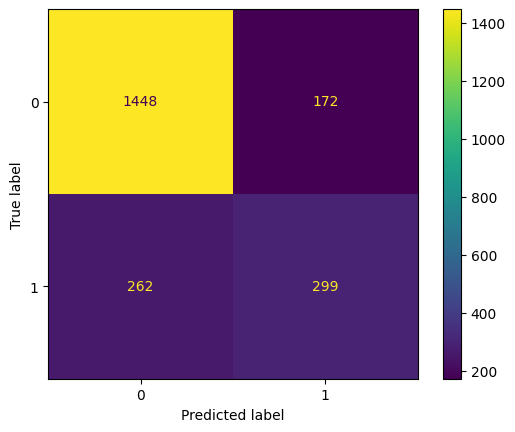

In [89]:
cm_log = confusion_matrix(y_test, y_pred_log)

ConfusionMatrixDisplay(cm_log).plot()

In [87]:
print("Random Forest")

print("Exactitud:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

print("\nReporte completo")
print(classification_report(y_test, y_pred_rf))

Random Forest
Exactitud: 0.7840440165061898
Precision: 0.6066350710900474
Recall: 0.4563279857397504
F1: 0.5208545269582909

Reporte completo
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1620
           1       0.61      0.46      0.52       561

    accuracy                           0.78      2181
   macro avg       0.72      0.68      0.69      2181
weighted avg       0.77      0.78      0.77      2181



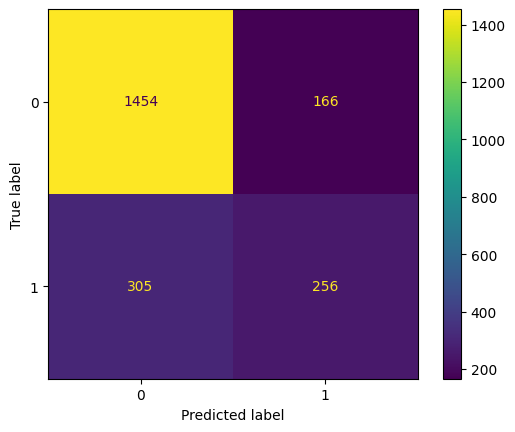

In [88]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(cm_rf).plot()

In [90]:
print(log_model.score(X_train_scaled, y_train))
print(log_model.score(X_test_scaled, y_test))

print(rf_model.score(X_train, y_train))
print(rf_model.score(X_test, y_test))

0.8067243413291388
0.8010087116001834
0.9921352732992529
0.7840440165061898


La Regresión Logística mostró un desempeño estable, con valores equilibrados de precisión, recall y F1-score, lo que indica buena capacidad de generalización.

Random Forest obtuvo una mayor exactitud, pero mostró una diferencia entre el rendimiento en entrenamiento y prueba, lo que sugiere posible overfitting. Esto puede deberse a que el modelo es más complejo y aprende demasiado los datos de entrenamiento.

La Regresión Logística requiere normalización debido a que es sensible a la escala de los datos, mientras que Random Forest no la requiere, ya que los modelos basados en árboles no dependen de distancias.

En general, el modelo con mejor desempeño fue Random Forest, aunque podría ajustarse para reducir el overfitting, por ejemplo limitando la profundidad del árbol o el número de estimadores.

In [91]:
import pandas as pd

coef = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": log_model.coef_[0]
})

coef = coef.sort_values(by="Coeficiente", ascending=False)

print(coef.head(10))

                                Variable  Coeficiente
17  internet.InternetService_Fiber optic     0.776495
14                         total_charges     0.664398
11              internet.StreamingMovies     0.274029
10                  internet.StreamingTV     0.250755
5                    phone.MultipleLines     0.213057
12                      paperlessBilling     0.190257
22       payment_method_Electronic check     0.155608
8              internet.DeviceProtection     0.081063
0                         senior_citizen     0.077348
4                     phone.PhoneService     0.028019


In [92]:
coef.sort_values(by="Coeficiente").head(10)

,Variable,Coeficiente
3,customer.tenure,-1.382826
18,internet.InternetService_No,-0.658846
20,contract_Two year,-0.540011
13,monthly_charges,-0.529135
15,Cuentas_Diarias,-0.498502
19,contract_One year,-0.270632
9,internet.TechSupport,-0.099234
6,internet.OnlineSecurity,-0.064968
23,payment_method_Mailed check,-0.056094
2,dependents,-0.049653


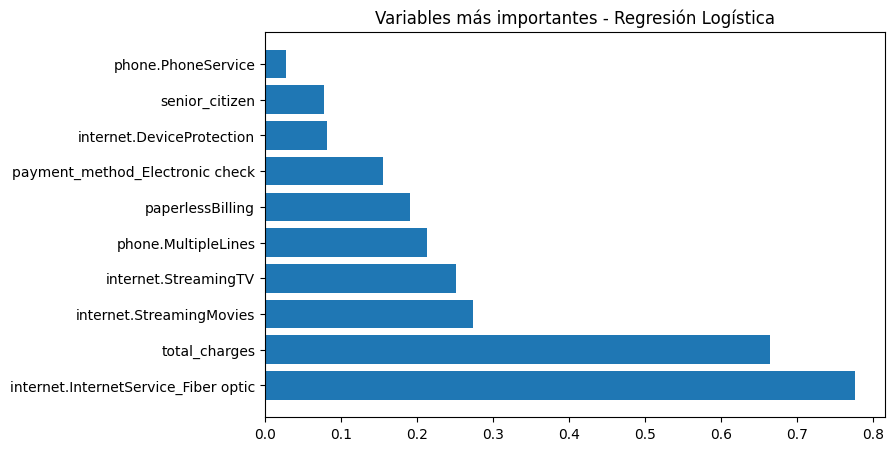

In [93]:
import matplotlib.pyplot as plt

coef_top = coef.head(10)

plt.figure(figsize=(8,5))
plt.barh(coef_top["Variable"], coef_top["Coeficiente"])
plt.title("Variables más importantes - Regresión Logística")
plt.show()

In [94]:
import pandas as pd

importances = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": rf_model.feature_importances_
})

importances = importances.sort_values(by="Importancia", ascending=False)

print(importances.head(10))

                                Variable  Importancia
14                         total_charges     0.171464
3                        customer.tenure     0.153157
13                       monthly_charges     0.150364
15                       Cuentas_Diarias     0.118405
17  internet.InternetService_Fiber optic     0.039576
22       payment_method_Electronic check     0.034745
20                     contract_Two year     0.032549
16                           gender_Male     0.026693
12                      paperlessBilling     0.024368
6                internet.OnlineSecurity     0.021645


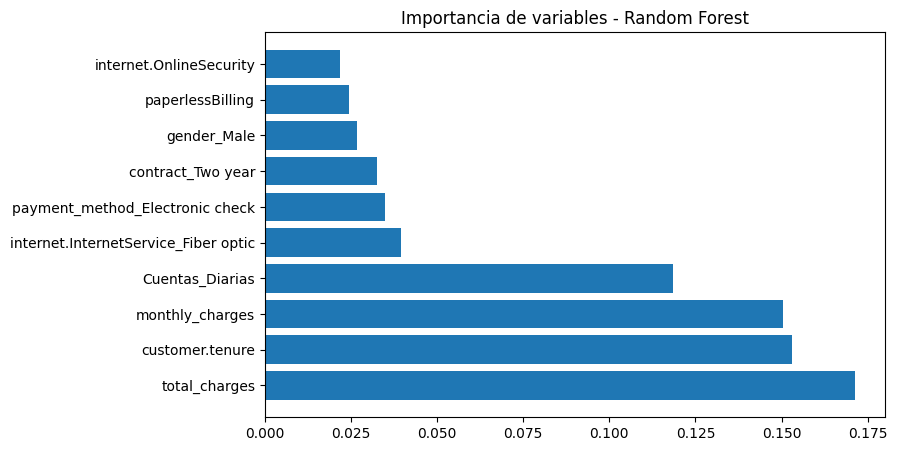

In [95]:
top_imp = importances.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_imp["Variable"], top_imp["Importancia"])
plt.title("Importancia de variables - Random Forest")
plt.show()

Se analizaron las variables más relevantes en los modelos seleccionados para entender qué factores influyen en la cancelación de clientes.

En la Regresión Logística, se evaluaron los coeficientes de cada variable. Los coeficientes positivos indican que la variable aumenta la probabilidad de cancelación, mientras que los coeficientes negativos indican que reduce dicha probabilidad. Se observó que variables como el tipo de contrato, el cargo mensual y el tiempo de permanencia tienen una fuerte influencia en la predicción.

En el modelo Random Forest, se utilizó la importancia de variables calculada por el algoritmo, basada en la reducción de impureza en los árboles de decisión. Las variables con mayor importancia fueron tenure, monthly_charges y total_charges, lo que indica que el tiempo como cliente y el gasto son factores clave en la cancelación.

### Análisis de la Importancia de las Variables

En este proyecto se realizó un análisis exploratorio y predictivo con el objetivo de identificar los factores que influyen en la cancelación de clientes (Churn) y construir modelos capaces de predecir dicho comportamiento. Para ello se realizó un proceso de limpieza de datos, transformación de variables categóricas, análisis de correlación, normalización de variables y entrenamiento de modelos de machine learning.

Primero se eliminaron columnas que no aportaban valor predictivo, como identificadores únicos, ya que no contribuyen a la predicción y pueden afectar el desempeño de los modelos. Posteriormente, las variables categóricas fueron transformadas a formato numérico mediante one-hot encoding, permitiendo su uso en algoritmos de aprendizaje automático.

Se evaluó la distribución de la variable objetivo, observándose un desbalance moderado entre clientes que cancelan y los que permanecen activos. Esto es importante porque puede afectar la capacidad del modelo para detectar correctamente la cancelación.

También se analizó la matriz de correlación, donde se observó que variables como el tiempo de permanencia (tenure), el gasto mensual (monthly_charges), el gasto total (total_charges) y el tipo de contrato presentan una relación importante con la cancelación. Los clientes con menor tiempo en la empresa y contratos mensuales mostraron mayor probabilidad de cancelar el servicio.

Se entrenaron dos modelos predictivos diferentes:

1. Regresión Logística, que requiere normalización de los datos, ya que es sensible a la escala de las variables.
2. Random Forest, que no requiere normalización porque los modelos basados en árboles no dependen de distancias entre variables.

El modelo Random Forest obtuvo mejor desempeño general en términos de exactitud y F1-score, lo que indica mayor capacidad para capturar relaciones complejas entre las variables. Sin embargo, se observó que este modelo puede presentar overfitting si no se controlan sus parámetros, debido a su alta complejidad. La regresión logística mostró un desempeño más estable y fácil de interpretar, aunque ligeramente inferior en precisión.

El análisis de importancia de variables mostró que los factores que más influyen en la cancelación son:

* Tiempo de permanencia del cliente (tenure)
* Tipo de contrato
* Gasto mensual
* Gasto total acumulado
* Servicios adicionales contratados
* Método de pago

Los clientes con menor tiempo en la empresa, contratos mensuales y cargos mensuales elevados presentan mayor probabilidad de cancelar. Por el contrario, los clientes con contratos a largo plazo y mayor antigüedad tienden a permanecer.

Con base en estos resultados, se proponen las siguientes estrategias de retención:

1. Incentivar contratos a largo plazo mediante descuentos o beneficios adicionales.
2. Implementar programas de fidelización para clientes nuevos durante los primeros meses, ya que es el periodo donde ocurre la mayor cancelación.
3. Revisar los planes con cargos mensuales altos para asegurar que el cliente perciba suficiente valor.
4. Ofrecer promociones personalizadas a clientes con alto riesgo de cancelación según el modelo predictivo.
5. Mejorar la experiencia del cliente en los primeros meses de servicio para reducir el abandono temprano.

En conclusión, el uso de modelos predictivos permitió identificar los factores más importantes en la cancelación de clientes y proponer acciones concretas para mejorar la retención. Random Forest mostró el mejor desempeño, mientras que la regresión logística permitió interpretar con mayor claridad la influencia de cada variable.
